In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
# Set up table plotting style
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300

In [2]:
# Load the data
results_df = pd.read_csv("/data/team01/ds340w/Aiden-Enhanced/model_performance_metrics/model_evaluation_full_results.csv", index_col=0)

In [3]:
print("Data loaded successfully!")
print(f"Shape: {results_df.shape}")
print(f"\nFirst few rows:")
print(results_df.head())

Data loaded successfully!
Shape: (12, 9)

First few rows:
          dataset   variant      model_key  accuracy  macro_precision  \
model                                                                   
dino          ham  Original  dino_Original  0.907093         0.853560   
dino          ham     GLIDE     dino_GLIDE  0.905095         0.870579   
dino   atlas_isic  Original  dino_Original  0.883576         0.876948   
dino   atlas_isic     GLIDE     dino_GLIDE  0.877339         0.859668   
swin          ham  Original  swin_Original  0.872128         0.857282   

       macro_recall  macro_f1  weighted_f1  num_samples  
model                                                    
dino       0.824233  0.836051     0.907268         1001  
dino       0.827512  0.844685     0.905048         1001  
dino       0.855548  0.861687     0.880713          962  
dino       0.857557  0.857368     0.874432          962  
swin       0.788150  0.794531     0.876969         1001  


In [4]:
results_df = results_df.reset_index()
results_df.columns
dataset_names = {
    'ham': 'HAM10000',
    'atlas_isic': 'Atlas+ISIC'
}

# Add formatted dataset names to the dataframe


In [5]:
# Clean up model names
results_df['model'] = results_df['model'].replace({
    'swin': 'Swin',
    'dino': 'DinoV2', 
    'vit': 'ViT'
})

results_df['dataset'] = results_df['dataset'].replace({
    'ham': 'HAM10000',
    'atlas_isic': 'Atlas+ISIC'
})

# Rename columns for clarity
results_df = results_df.rename(columns={
    'macro_precision': 'precision',
    'macro_recall': 'recall', 
    'macro_f1': 'f1'
})

# Create a combined model+dataset+glide identifier
results_df['model_dataset'] = results_df['model'] + '_' + results_df['dataset']

print("Data prepared!")
print(f"\nUnique models: {results_df['model'].unique()}")
print(f"Unique datasets: {results_df['dataset'].unique()}")
print(f"Variants: {results_df['variant'].unique()}")

Data prepared!

Unique models: <ArrowStringArray>
['DinoV2', 'Swin', 'ViT']
Length: 3, dtype: str
Unique datasets: <ArrowStringArray>
['HAM10000', 'Atlas+ISIC']
Length: 2, dtype: str
Variants: <ArrowStringArray>
['Original', 'GLIDE']
Length: 2, dtype: str


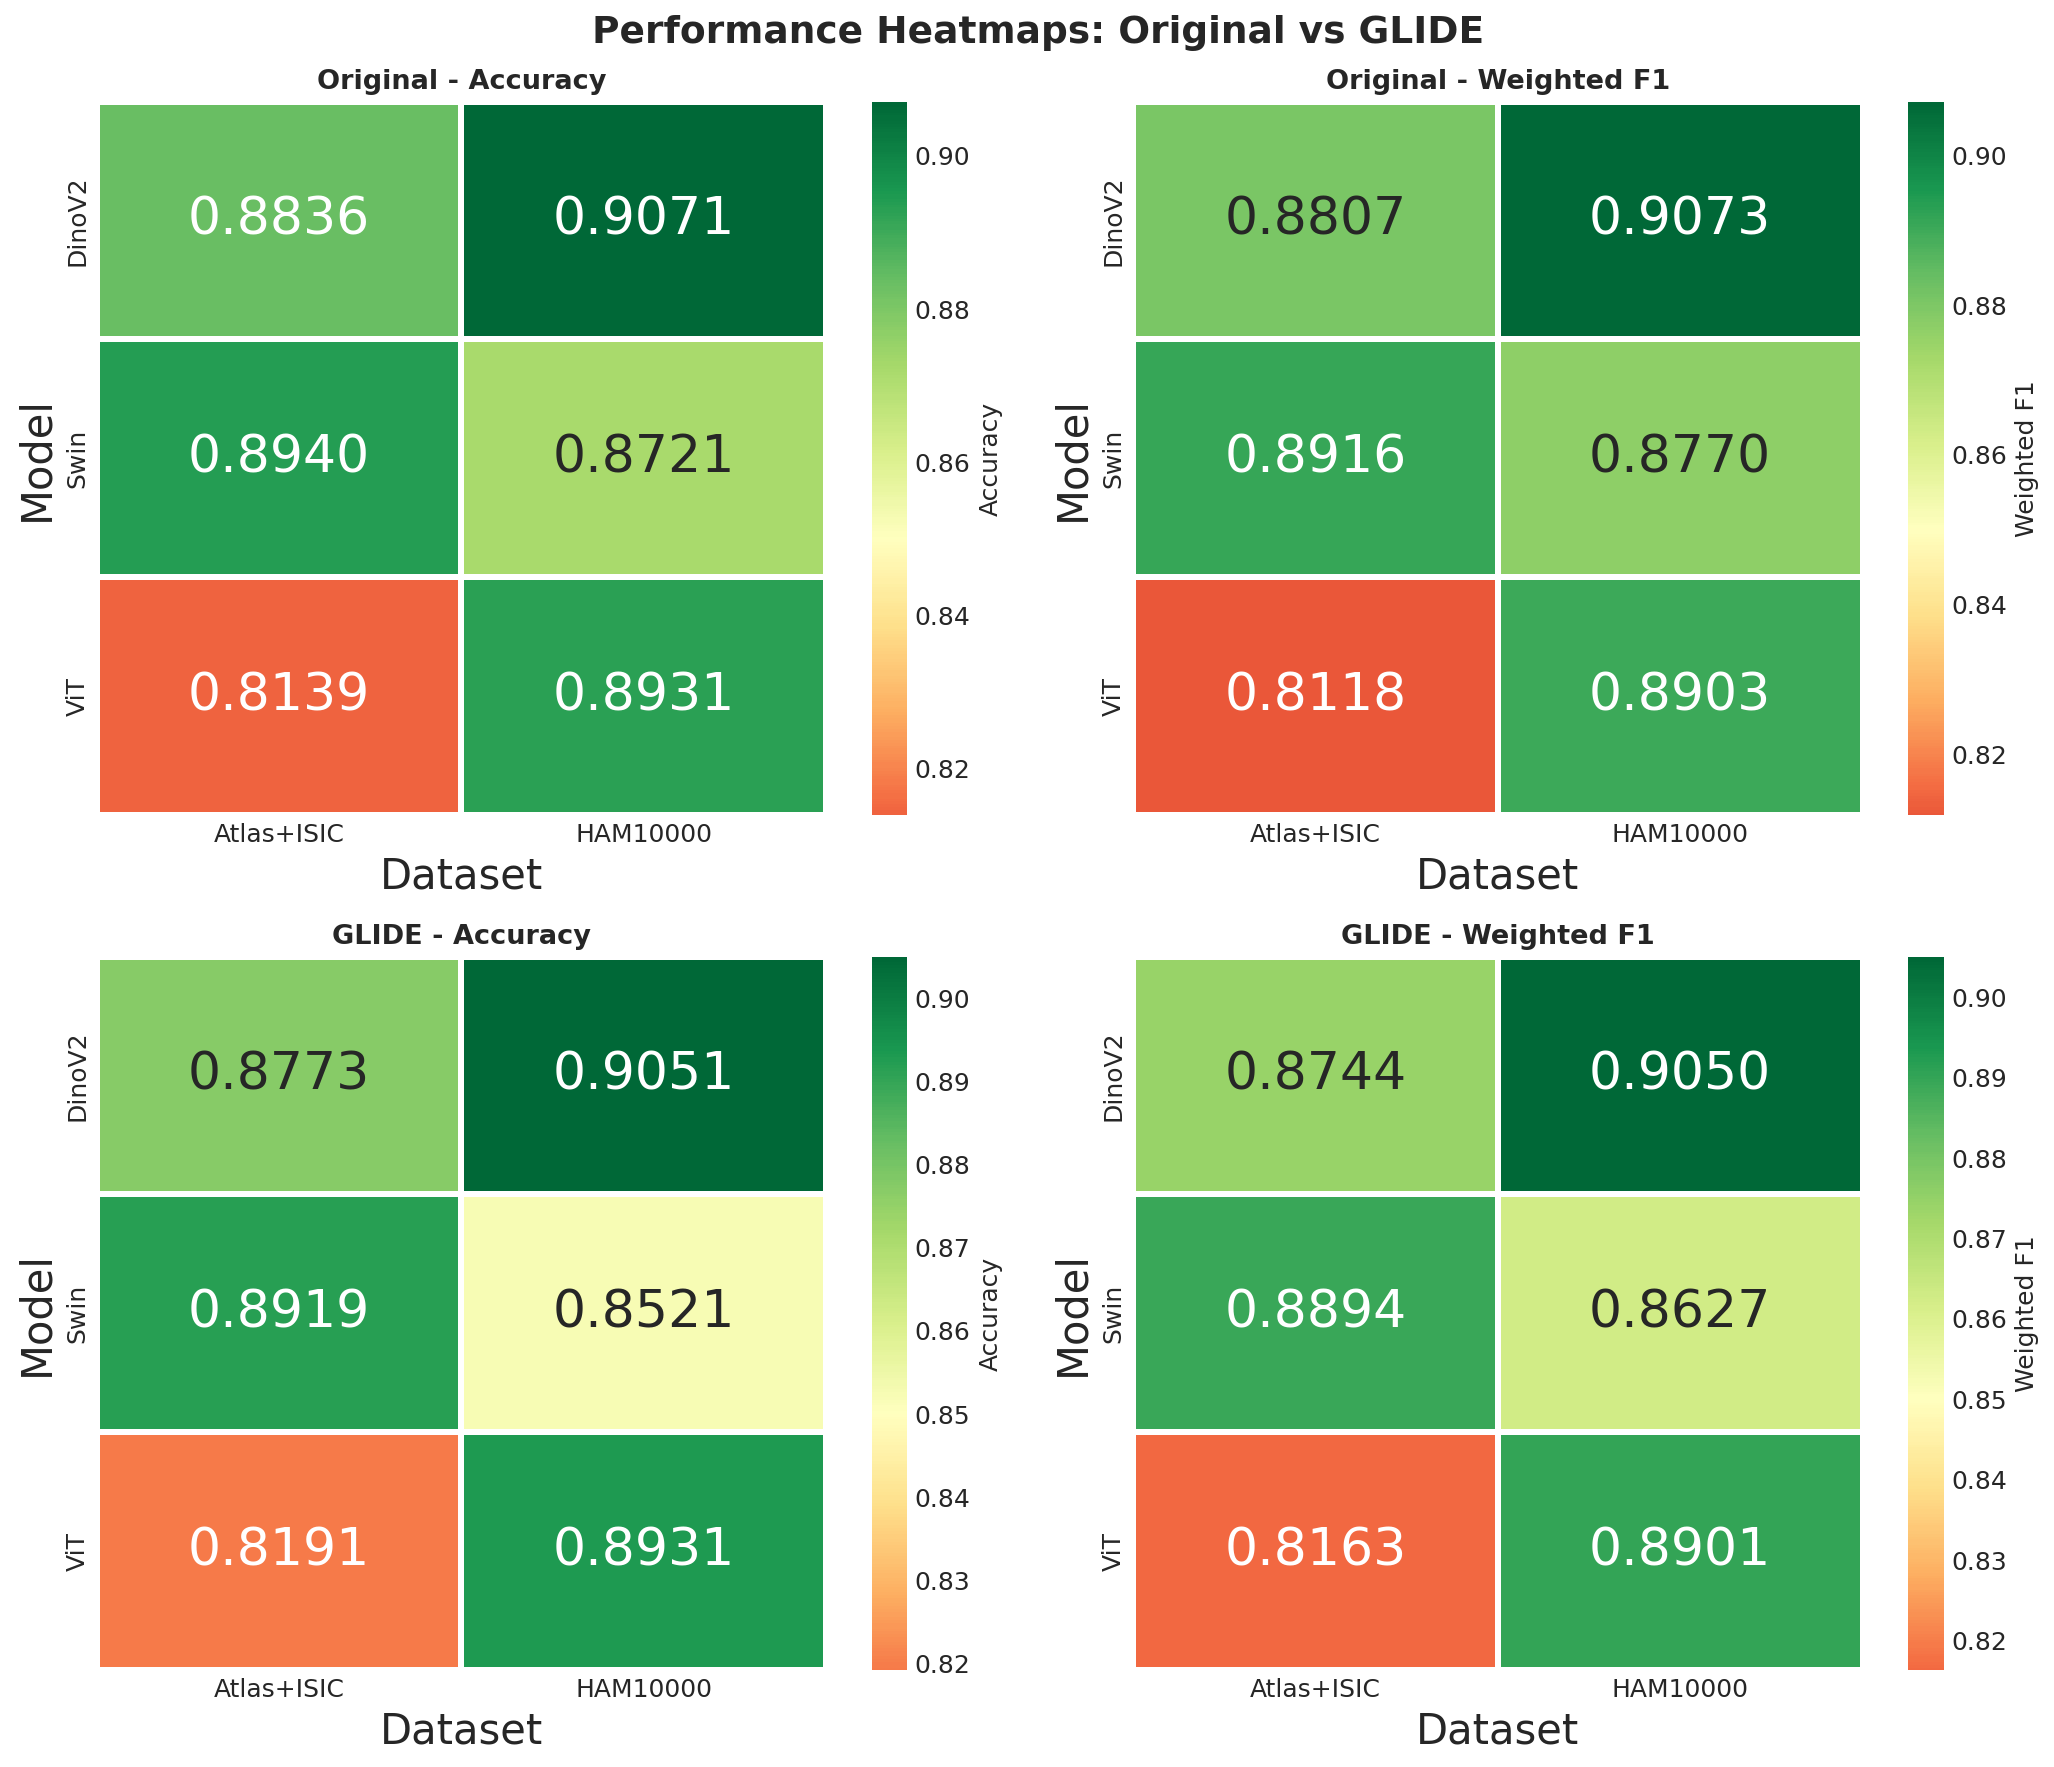

In [6]:
# Create heatmaps for Original and GLIDE variants
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Performance Heatmaps: Original vs GLIDE', fontsize=18, fontweight='bold')

variants = ['Original', 'GLIDE']
metrics_heat = ['accuracy', 'weighted_f1']
metric_names = ['Accuracy', 'Weighted F1']

for row_idx, variant in enumerate(variants):
    for col_idx, (metric, metric_name) in enumerate(zip(metrics_heat, metric_names)):
        ax = axes[row_idx, col_idx]
        
        # Pivot data for heatmap
        subset = results_df[results_df['variant'] == variant]
        pivot_data = subset.pivot(index='model', columns='dataset', values=metric)
        
        sns.heatmap(pivot_data, annot=True, fmt='.4f', cmap='RdYlGn', 
                   center=0.85, linewidths=2, cbar_kws={'label': metric_name},
                   ax=ax, annot_kws={'size': 25})
        ax.set_title(f'{variant} - {metric_name}', fontsize=13, fontweight='bold')
        ax.set_xlabel('Dataset', fontsize=20)
        ax.set_ylabel('Model', fontsize=20)

plt.tight_layout()
plt.savefig('heatmaps_original_vs_glide.png', dpi=300, bbox_inches='tight')
plt.show()

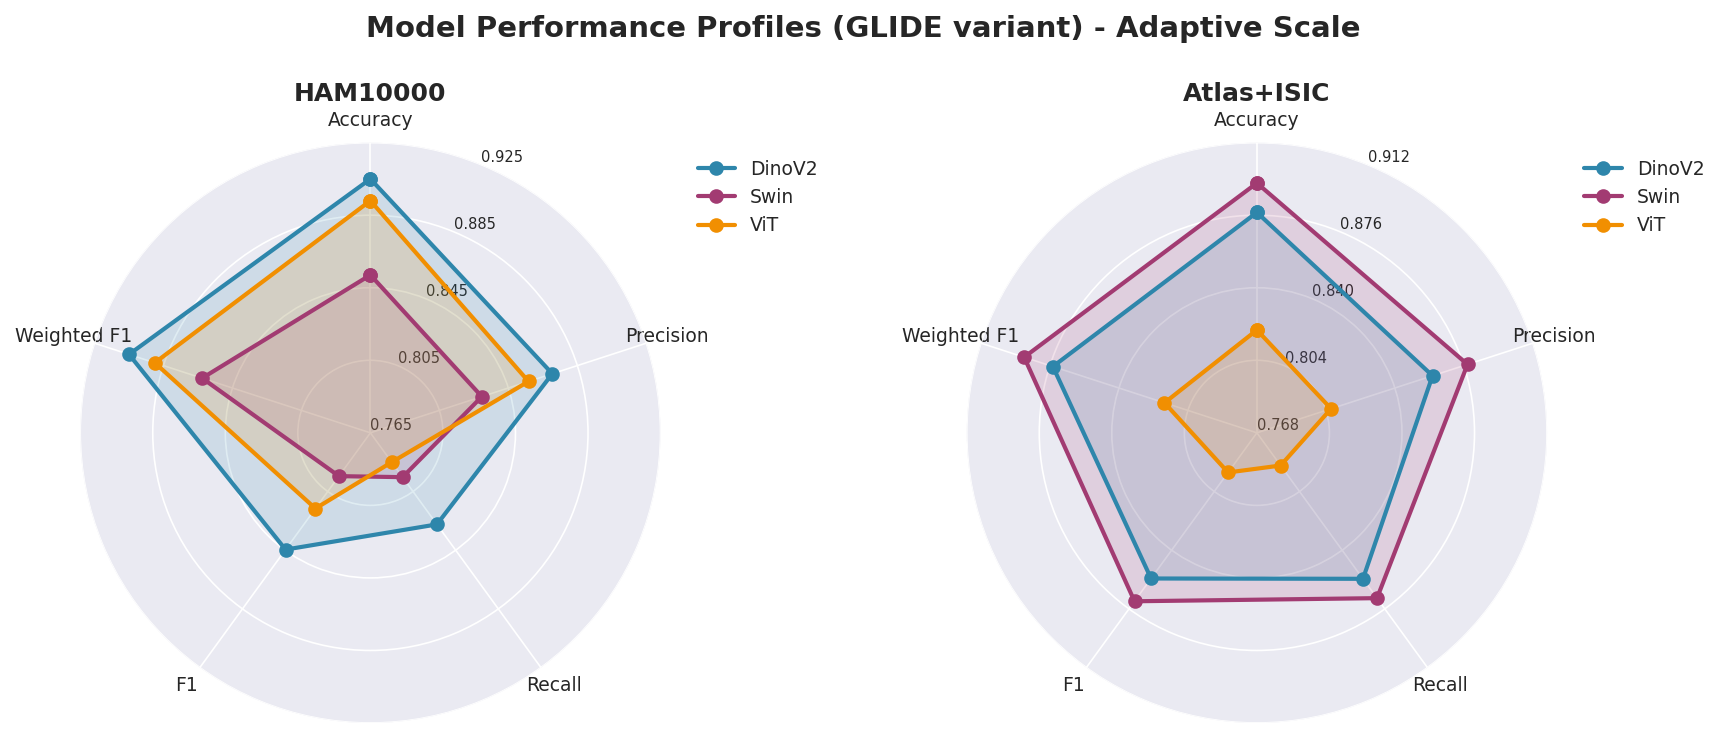

In [7]:
# Radar chart for comparing models within each dataset
from math import pi

def radar_chart(data_dict, title, ax, use_global_scale=False, global_min=0.7, global_max=1.0):
    """
    Create radar chart with flexible scaling
    
    Parameters:
    - data_dict: dict of model metrics
    - title: chart title
    - ax: matplotlib axis
    - use_global_scale: if True, use fixed scale (0.7-1.0), else use min-max scaling per dataset
    - global_min: minimum value for global scale
    - global_max: maximum value for global scale
    """
    categories = ['Accuracy', 'Precision', 'Recall', 'F1', 'Weighted F1']
    N = len(categories)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=9)
    
    # Determine y-axis limits
    if use_global_scale:
        y_min, y_max = global_min, global_max
    else:
        # Find min and max across all metrics for this dataset
        all_values = []
        for metrics in data_dict.values():
            all_values.extend([metrics['accuracy'], metrics['precision'], 
                              metrics['recall'], metrics['f1'], metrics['weighted_f1']])
        y_min = min(all_values) - 0.02
        y_max = max(all_values) + 0.02
        # Ensure y_min is at least 0.7 for reasonable comparison
        y_min = max(0.7, y_min)
        y_max = min(1.0, y_max)
    
    ax.set_ylim(y_min, y_max)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=20)
    
    colors = ['#2E86AB', '#A23B72', '#F18F01']
    for idx, (model, metrics) in enumerate(data_dict.items()):
        values = [metrics['accuracy'], metrics['precision'], 
                  metrics['recall'], metrics['f1'], metrics['weighted_f1']]
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, label=model, 
               color=colors[idx % len(colors)])
        ax.fill(angles, values, alpha=0.15, color=colors[idx % len(colors)])
    
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=9)
    
    # Add grid lines at meaningful intervals
    if not use_global_scale:
        # Add custom grid lines
        y_ticks = np.linspace(y_min, y_max, 5)
        ax.set_yticks(y_ticks)
        ax.set_yticklabels([f'{tick:.3f}' for tick in y_ticks], fontsize=7)


fig, axes = plt.subplots(1, 2, figsize=(12, 5), subplot_kw={'projection': 'polar'})
fig.suptitle('Model Performance Profiles (GLIDE variant) - Adaptive Scale', 
             fontsize=14, fontweight='bold')

for idx, dataset in enumerate(results_df['dataset'].unique()):
    subset = results_df[(results_df['dataset'] == dataset) & (results_df['variant'] == 'GLIDE')]
    model_data = {}
    for _, row in subset.iterrows():
        model_data[row['model']] = {
            'accuracy': row['accuracy'],
            'precision': row['precision'],
            'recall': row['recall'],
            'f1': row['f1'],
            'weighted_f1': row['weighted_f1']
        }
    radar_chart(model_data, dataset_names.get(dataset, dataset), axes[idx], 
                use_global_scale=False)

plt.tight_layout()
plt.savefig('radar_charts_glide_adaptive_scale.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
def create_table_image(df, title, filename, col_widths=None, figsize=(12, 4)):
    """
    Create a clean table image from a dataframe with proper sorting
    """
    # Make a copy to avoid modifying original
    df_sorted = df.copy()
    
    # Check if we have model and variant columns for sorting
    if 'Model' in df_sorted.columns and 'Variant' in df_sorted.columns:
        # Sort by Model, then by Variant (Original before GLIDE)
        variant_order = {'Original': 0, 'GLIDE': 1}
        df_sorted['Variant_Order'] = df_sorted['Variant'].map(variant_order)
        df_sorted = df_sorted.sort_values(['Model', 'Variant_Order'])
        df_sorted = df_sorted.drop('Variant_Order', axis=1)
    
    elif 'Model' in df_sorted.columns and 'Dataset' in df_sorted.columns and 'Variant' not in df_sorted.columns:
        # For pivot tables, sort by Model
        df_sorted = df_sorted.sort_values('Model')
    
    elif 'Model' in df_sorted.columns:
        # Just sort by Model
        df_sorted = df_sorted.sort_values('Model')
    
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis('off')
    ax.axis('tight')
    
    # Create table
    if col_widths:
        table = ax.table(cellText=df_sorted.values,
                        colLabels=df_sorted.columns,
                        cellLoc='center',
                        loc='center',
                        colWidths=col_widths)
    else:
        table = ax.table(cellText=df_sorted.values,
                        colLabels=df_sorted.columns,
                        cellLoc='center',
                        loc='center')
    
    # Style the table
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)
    
    # Color header row
    for (i, j), cell in table.get_celld().items():
        if i == 0:  # header row
            cell.set_facecolor('#2c3e50')
            cell.set_text_props(weight='bold', color='white')
        else:
            cell.set_facecolor('#f9f9f9' if i % 2 == 0 else 'white')
            cell.set_text_props(color='#333333')
        cell.set_edgecolor('#cccccc')
        cell.set_linewidth(0.5)
    
    # Add title
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20, color='#2c3e50')
    
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    print(f"✅ Saved: {filename}")

main_table = results_df[['model', 'dataset', 'variant', 'accuracy', 'precision', 'recall', 'f1', 'weighted_f1']].copy()
main_table = main_table.round(4)
main_table = main_table.sort_values(['dataset', 'model', 'variant'])

# Rename columns for display
main_table.columns = ['Model', 'Dataset', 'Variant', 'Accuracy', 'Precision', 'Recall', 'F1', 'Weighted F1']

create_table_image(main_table, 
                   'Model Performance - Complete Overview',
                   'table_full_performance.png',
                   figsize=(14, 4))

✅ Saved: table_full_performance.png
